In [11]:
# 注册自定义 highfreq_ops.Cut，并写入 C.custom_ops；同时强制单线程/线程后端，避免多进程丢失注册
import sys, os
sys.path.append(r"C:\Users\ASUS\qlib\examples\highfreq")
from qlib.data.ops import Operators, register_all_ops
from qlib.config import C
from highfreq_ops import Cut as HFCut

# 先在当前进程注册（覆盖同名内置 Cut）
Operators.register([HFCut])

# 配置自定义算子，并刷新算子注册
C.custom_ops = [{"class": "Cut", "module_path": "highfreq_ops"}]
register_all_ops(C)

# 关键：避免 joblib 以多进程方式 spawn 子进程（Windows 下会丢全局注册）
C.kernels = 1
C.joblib_backend = "threading"

print("highfreq_ops.Cut registered; kernels=1, backend=threading.")


highfreq_ops.Cut registered; kernels=1, backend=threading.


In [1]:
import fire

import qlib
import pickle
from qlib.constant import REG_CN
from qlib.config import HIGH_FREQ_CONFIG

from qlib.utils import init_instance_by_config
from qlib.data.dataset.handler import DataHandlerLP
from qlib.data.ops import Operators
from qlib.data.data import Cal
from qlib.tests.data import GetData

from highfreq_ops import get_calendar_day, DayLast, FFillNan, BFillNan, Date, Select, IsNull, Cut

天勤数据下载

In [3]:
# ============================================
# KQDownloader_fixed.py 调用区块（Qlib兼容）
# ============================================
from pathlib import Path
import os
import sys
import subprocess
from datetime import datetime

# 自动识别路径（支持从 qlib/examples/highfreq/ 中运行）
nb_cwd = Path.cwd()
if (nb_cwd / 'scripts').exists() and (nb_cwd / 'qlib').exists():
    PROJECT_ROOT = nb_cwd
else:
    PROJECT_ROOT = nb_cwd
    if PROJECT_ROOT.name.lower() == 'highfreq' and PROJECT_ROOT.parent.name.lower() == 'examples':
        PROJECT_ROOT = PROJECT_ROOT.parents[1]

# === 参数配置 ===
SCRIPT = PROJECT_ROOT / "scripts" / "data_collector" / "KQ" / "KQdownloader.py"
RAW_DIR = PROJECT_ROOT.parent / "kq_raw_data"       # 临时保存天勤原始CSV
QLIB_DIR = PROJECT_ROOT.parent / "qlib_data"        # 输出为Qlib标准数据
POOL_CSV = Path(r"C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv")

START = "2025-01-01"
END = "2025-09-30"
INTERVAL = "1min"          # Qlib分钟级数据
USERNAME = "xclight"
PASSWORD = "xclight666"
LIMIT_NUMS = None         # 下载股票数量限制（None 表示全部）



# === benchmark 配置 ===
BENCHMARK_CODE = "SSE.000300"  # 沪深300
BENCHMARK_DIR = QLIB_DIR / "benchmark"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)  # 确保目录存在
BENCHMARK_FILE = BENCHMARK_DIR / f"{BENCHMARK_CODE}.csv"

# === 路径检查 ===
RAW_DIR.mkdir(parents=True, exist_ok=True)
QLIB_DIR.mkdir(parents=True, exist_ok=True)

print("📁 当前工作路径:", nb_cwd)
print("🧭 项目根目录:", PROJECT_ROOT)
print("📜 使用脚本:", SCRIPT)
print("📦 原始数据目录:", RAW_DIR)
print("📊 Qlib数据输出目录:", QLIB_DIR)
print("📋 股票池:", POOL_CSV)
print("📊 Benchmark:", BENCHMARK_CODE)


# === 构建命令 ===
cmd = [
    sys.executable, str(SCRIPT), 'run',
    '--source_dir', str(RAW_DIR),
    '--target_dir', str(QLIB_DIR),
    '--csv_stock_pool', str(POOL_CSV),
    '--start', START,
    '--end', END,
    '--interval', INTERVAL,
    '--username', USERNAME,
    '--password', PASSWORD,
    '--benchmark', BENCHMARK_CODE,  # ⚙️ 新增 benchmark 参数
    '--benchmark_dir', str(BENCHMARK_DIR)  # ⚙️ benchmark 存放路径
]
if LIMIT_NUMS:
    cmd += ['--limit_nums', str(LIMIT_NUMS)]

print("\n🚀 启动下载命令:\n", ' '.join(map(str, cmd)), "\n")

# === 启动下载过程（实时输出日志） ===
with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1) as p:
    for line in p.stdout:
        print(line, end='')
    rc = p.wait()
    if rc != 0:
        raise RuntimeError(f"❌ Downloader failed with return code {rc}")

print("\n✅ 数据下载与 Qlib 格式转换已完成！")
print(f"📂 Qlib 数据位置: {QLIB_DIR}")
print(f"📊 Benchmark 数据位置: {BENCHMARK_FILE}")


📁 当前工作路径: c:\Users\ASUS\qlib\examples\highfreq
🧭 项目根目录: c:\Users\ASUS\qlib
📜 使用脚本: c:\Users\ASUS\qlib\scripts\data_collector\KQ\KQdownloader.py
📦 原始数据目录: c:\Users\ASUS\kq_raw_data
📊 Qlib数据输出目录: c:\Users\ASUS\qlib_data
📋 股票池: C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv
📊 Benchmark: SSE.000300

🚀 启动下载命令:
 c:\Users\ASUS\miniconda3\python.exe c:\Users\ASUS\qlib\scripts\data_collector\KQ\KQdownloader.py run --source_dir c:\Users\ASUS\kq_raw_data --target_dir c:\Users\ASUS\qlib_data --csv_stock_pool C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv --start 2025-01-01 --end 2025-09-30 --interval 1min --username xclight --password xclight666 --benchmark SSE.000300 --benchmark_dir c:\Users\ASUS\qlib_data\benchmark 

在使用天勤量化之前，默认您已经知晓并同意以下免责条款，如果不同意请立即停止使用：https://www.shinnytech.com/blog/disclaimer/
2025-10-11 13:46:52.260 | INFO     | __main__:run:125 - ⚙️ 未设置 limit_nums，默认下载全部股票
2025-10-11 13:46:52.260 | INFO     | __main__:run:127 - 📊 股票数: 5

In [39]:
#下载数据预处理 转化成qlib数据格式完全一样
import os
import pandas as pd
import numpy as np
from pathlib import Path
import struct

# ====== 天勤数据目录（直接覆盖） ======
KQ_DATA_DIR = Path(r"C:\Users\ASUS\qlib_data")  # 天勤下载后的根目录
RAW_DIR = Path(r"C:\Users\ASUS\kq_raw_data")

# ====== 工具函数 ======
def market_prefix_convert(code: str):
    """sse.xxx / szse.xxx → SHxxx / SZxxx (文件夹名用大写)"""
    code = code.upper()
    if code.startswith("SSE."):
        return "SH" + code.split(".")[1]
    elif code.startswith("SZSE."):
        return "SZ" + code.split(".")[1]
    else:
        return code.upper()

def market_prefix_convert_upper(code: str):
    """sse.xxx / szse.xxx → SHxxx / SZxxx (all.txt用大写)"""
    code = code.upper()
    if code.startswith("SSE."):
        return "SH" + code.split(".")[1]
    elif code.startswith("SZSE."):
        return "SZ" + code.split(".")[1]
    else:
        return code.upper()

# 测试转换函数
print("🧪 测试转换函数:")
test_codes = ["sse.000300", "szse.000001", "SSE.600519", "SZSE.000858"]
for code in test_codes:
    converted_folder = market_prefix_convert(code)
    converted_file = market_prefix_convert_upper(code)
    print(f"   {code} → 文件夹: {converted_folder}, all.txt: {converted_file}")

def write_bin(series: pd.Series, path: Path):
    """写入 float32 二进制"""
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = series.astype(np.float32).to_numpy()
    with open(path, "wb") as f:
        f.write(struct.pack(f"{len(arr)}f", *arr))

def read_bin(fp):
    return np.fromfile(fp, dtype=np.float32)

# ====== 1. 日历文件保持不变 ======
print(f"✅ 日历文件已存在: {KQ_DATA_DIR / 'calendars' / '1min.txt'}")

# ====== 2. instruments/all.txt 转换 ======
inst_src = KQ_DATA_DIR / "instruments" / "all.txt"

# 使用更灵活的读取方式处理格式问题
print(f"🔍 检查股票池文件格式: {inst_src}")

# 先读取原始内容查看格式
with open(inst_src, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
print(f"   文件总行数: {len(lines)}")
print(f"   前3行原始内容:")
for i in range(min(3, len(lines))):
    print(f"     {repr(lines[i].strip())}")

# 手动解析每行，处理引号和格式问题
parsed_data = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    
    # 分割字段，处理引号问题
    parts = line.split('\t')
    if len(parts) >= 3:
        instrument = parts[0].strip()
        start_time = parts[1].strip()
        end_time = parts[2].strip().strip('"').strip()  # 去除引号和空格
        
        # 清理end_time中的多余内容
        if '"' in end_time:
            end_time = end_time.split('"')[0].strip()
        
        parsed_data.append([instrument, start_time, end_time])
    else:
        print(f"⚠️ 跳过格式异常的行: {line}")

# 创建DataFrame
inst_df = pd.DataFrame(parsed_data, columns=["instrument", "start", "end"])

print(f"📝 解析完成，数据形状: {inst_df.shape}")
print(f"   前5行解析结果:")
for i in range(min(5, len(inst_df))):
    print(f"     {inst_df.iloc[i].tolist()}")

# 转换股票代码格式（all.txt用大写）
inst_df["instrument"] = inst_df["instrument"].apply(market_prefix_convert_upper)

# 保存转换后的文件
inst_df.to_csv(inst_src, sep="\t", header=False, index=False)
print(f"✅ 股票池格式已转换: {inst_src}")
print(f"   转换后形状: {inst_df.shape}")
print(f"   前5支股票: {inst_df['instrument'].head().tolist()}")

# ====== 3. features 特征字段补齐 ======
#修复后 原始写入bin第一行数据为0 现在改成直接从csv读取写入bin
feature_src = KQ_DATA_DIR / "features"
csv_dir = RAW_DIR  # CSV 文件目录

# 删除benchmark文件夹（如果存在）
benchmark_dir = KQ_DATA_DIR / "benchmark"
if benchmark_dir.exists():
    import shutil
    shutil.rmtree(benchmark_dir)
    print(f"🗑️ 已删除benchmark文件夹: {benchmark_dir}")

print(f"📁 开始处理特征目录: {feature_src}")

# 处理每个股票的特征文件（先处理，后重命名）
print(f"📁 开始处理特征文件...")

"""
for inst_dir in feature_src.iterdir():
    if not inst_dir.is_dir():
        continue

    files = {f.stem.split(".")[0]: f for f in inst_dir.glob("*.1min.bin")}
    print(f"📈 处理 {inst_dir.name}: {list(files.keys())}")

    # 加载基础字段
    open_ = read_bin(files.get("open"))
    high = read_bin(files.get("high"))
    low = read_bin(files.get("low"))
    close = read_bin(files.get("close"))
    vol = read_bin(files.get("volume"))

    # 构造补充字段
    factor = np.ones_like(close, dtype=np.float32)
    paused = np.zeros_like(close, dtype=np.float32)
    paused_num = np.zeros_like(close, dtype=np.float32)
    change = np.concatenate([[0], np.diff(close)])  # ✅ 与 Qlib 一致：涨跌额

    # 写入
    write_bin(pd.Series(open_), inst_dir / "open.1min.bin")
    write_bin(pd.Series(high), inst_dir / "high.1min.bin")
    write_bin(pd.Series(low), inst_dir / "low.1min.bin")
    write_bin(pd.Series(close), inst_dir / "close.1min.bin")
    write_bin(pd.Series(vol), inst_dir / "volume.1min.bin")
    write_bin(pd.Series(factor), inst_dir / "factor.1min.bin")
    write_bin(pd.Series(paused), inst_dir / "paused.1min.bin")
    write_bin(pd.Series(paused_num), inst_dir / "paused_num.1min.bin")
    write_bin(pd.Series(change), inst_dir / "change.1min.bin")

print(f"✅ 特征文件处理完成")
"""
first_stock_done = False 

# 遍历 CSV 文件，批量生成 bin 文件
for csv_path in csv_dir.glob("*.csv"):  # 遍历所有 CSV
    inst_name = csv_path.stem  # 例如 SSE_000300
    inst_dir = feature_src / inst_name
    inst_dir.mkdir(parents=True, exist_ok=True)

    import pandas as pd
    df = pd.read_csv(csv_path)
    

    # 将 CSV 中的各列转换为 numpy float32
    open_np = df["open"].to_numpy(dtype=np.float32)
    high_np = df["high"].to_numpy(dtype=np.float32)
    low_np = df["low"].to_numpy(dtype=np.float32)
    close_np = df["close"].to_numpy(dtype=np.float32)
    vol_np = df["volume"].to_numpy(dtype=np.float32)

    # 构造补充字段
    factor_np = np.ones_like(close_np, dtype=np.float32)
    paused_np = np.zeros_like(close_np, dtype=np.float32)
    paused_num_np = np.zeros_like(close_np, dtype=np.float32)
    change_np = np.concatenate([[0], np.diff(close_np)])

    bin_data_list = [
        (open_np, "open"), (high_np, "high"), (low_np, "low"),
        (close_np, "close"), (vol_np, "volume"),
        (factor_np, "factor"), (paused_np, "paused"),
        (paused_num_np, "paused_num"), (change_np, "change")
    ]

    # 写入 bin 文件
    for arr, name in bin_data_list:
        path = inst_dir / f"{name}.1min.bin"
        write_bin(pd.Series(arr), path)

    # 打印第一个股票的 bin 数据前5行
    if not first_stock_done:
        print(f"\n📄 示例: {inst_name} 9 个 bin 文件前5条数据:")
        for arr, name in bin_data_list:
            print(f"   {name}: {arr[:5]}")
        first_stock_done = True

print(f"✅ 特征文件处理完成")

# 现在重命名所有文件夹为大写格式
print(f"\n🔄 开始重命名文件夹为大写格式...")

# 收集所有需要重命名的目录
rename_operations = []
print(f"🔍 检查所有目录:")
for inst_dir in feature_src.iterdir():
    if not inst_dir.is_dir():
        continue
    
    # 转换文件夹名称为Qlib标准格式（大写）
    inst_code = market_prefix_convert(inst_dir.name)
    target_dir = feature_src / inst_code
    
    print(f"   目录: {inst_dir.name} → 转换后: {inst_code}")
    
    if inst_dir != target_dir:
        rename_operations.append((inst_dir, target_dir))
        print(f"   ✅ 需要重命名: {inst_dir.name} → {inst_code}")
    else:
        print(f"   ⏭️ 无需重命名: {inst_dir.name}")

print(f"🔄 需要重命名的目录数量: {len(rename_operations)}")

# 显示重命名计划
if rename_operations:
    print(f"📋 重命名计划:")
    for i, (inst_dir, target_dir) in enumerate(rename_operations[:10]):  # 只显示前10个
        print(f"   {i+1}. {inst_dir.name} → {target_dir.name}")
    if len(rename_operations) > 10:
        print(f"   ... 还有 {len(rename_operations) - 10} 个目录")

# 执行重命名操作
for inst_dir, target_dir in rename_operations:
    try:
        print(f"📝 重命名: {inst_dir.name} → {target_dir.name}")
        os.rename(inst_dir, target_dir)
    except Exception as e:
        print(f"❌ 重命名失败 {inst_dir.name}: {e}")

print(f"✅ 目录重命名完成")

print("🎉 天勤分钟数据预处理完成，已覆盖为 Qlib 兼容格式！")

# ====== 4. 验证数据转换结果 ======
print("\n🔍 开始验证数据转换结果...")

# 验证日历文件
calendar_file = KQ_DATA_DIR / "calendars" / "1min.txt"
if calendar_file.exists():
    with open(calendar_file, 'r') as f:
        calendar_lines = f.readlines()
    print(f"✅ 日历文件验证: {len(calendar_lines)} 个交易日")
    print(f"   最早交易日: {calendar_lines[0].strip()}")
    print(f"   最晚交易日: {calendar_lines[-1].strip()}")
else:
    print("❌ 日历文件不存在")

# 验证股票池文件
instruments_file = KQ_DATA_DIR / "instruments" / "all.txt"
if instruments_file.exists():
    inst_df_check = pd.read_csv(instruments_file, header=None, sep='\t')
    print(f"✅ 股票池文件验证: {len(inst_df_check)} 支股票")
    print(f"   前5支股票: {inst_df_check.iloc[:5, 0].tolist()}")
else:
    print("❌ 股票池文件不存在")

# 验证特征文件
feature_dir = KQ_DATA_DIR / "features"
if feature_dir.exists():
    stock_dirs = [d for d in feature_dir.iterdir() if d.is_dir()]
    print(f"✅ 特征目录验证: {len(stock_dirs)} 个股票目录")
    
    # 检查第一个股票的特征文件
    if stock_dirs:
        first_stock = stock_dirs[0]
        feature_files = list(first_stock.glob("*.1min.bin"))
        print(f"   示例股票 {first_stock.name} 的特征文件:")
        for f in feature_files:
            file_size = f.stat().st_size
            data_points = file_size // 4  # float32 = 4 bytes
            print(f"     {f.name}: {data_points} 个数据点")
            
        # 验证数据内容
        try:
            close_data = read_bin(first_stock / "close.1min.bin")
            print(f"    {first_stock.name} close 数据范围: {close_data.min():.2f} ~ {close_data.max():.2f}")
            print(f"    数据点数: {len(close_data)}")
        except Exception as e:
            print(f"   ❌ 读取数据失败: {e}")
else:
    print("❌ 特征目录不存在")

# 验证benchmark文件夹（已删除）
benchmark_dir = KQ_DATA_DIR / "benchmark"
if benchmark_dir.exists():
    print("⚠️ Benchmark文件夹仍然存在")
else:
    print("✅ Benchmark文件夹已删除（符合Qlib标准）")

# 最终验证总结
print(f"\n📊 数据转换验证总结:")
print(f"   数据目录: {KQ_DATA_DIR}")
print(f"   日历文件: {'✅' if calendar_file.exists() else '❌'}")
print(f"   股票池文件: {'✅' if instruments_file.exists() else '❌'}")
print(f"   特征目录: {'✅' if feature_dir.exists() else '❌'}")
print(f"   Benchmark文件夹: {'❌' if benchmark_dir.exists() else '✅'} (已删除)")

# 检查文件夹命名格式
print(f"\n🔍 检查文件夹命名格式:")
if feature_dir.exists():
    stock_dirs = [d for d in feature_dir.iterdir() if d.is_dir()]
    if stock_dirs:
        print(f"   前5个文件夹名称:")
        for i, d in enumerate(stock_dirs[:5]):
            print(f"     {i+1}. {d.name}")
        
        # 检查是否符合Qlib标准格式（文件夹用大写）
        non_standard = [d.name for d in stock_dirs if not (d.name.startswith('SH') or d.name.startswith('SZ'))]
        if non_standard:
            print(f"   ⚠️ 发现非标准格式文件夹: {non_standard[:5]}")
        else:
            print(f"   ✅ 所有文件夹都符合Qlib标准格式 (SH/SZ开头，大写)")
    else:
        print("   ❌ 没有找到股票文件夹")

# 检查是否有任何文件被修改
import time
current_time = time.time()
recent_files = []

for root, dirs, files in os.walk(KQ_DATA_DIR):
    for file in files:
        file_path = Path(root) / file
        if file_path.stat().st_mtime > current_time - 300:  # 5分钟内的文件
            recent_files.append(str(file_path))

if recent_files:
    print(f"\n🔄 最近5分钟内修改的文件 ({len(recent_files)} 个):")
    for f in recent_files[:10]:  # 只显示前10个
        print(f"   {f}")
    if len(recent_files) > 10:
        print(f"   ... 还有 {len(recent_files) - 10} 个文件")
else:
    print(f"\n⚠️ 警告: 最近5分钟内没有文件被修改，可能数据转换未成功执行")

print("\n🎯 验证完成！如果所有项目都显示 ✅，说明数据转换成功。")



🧪 测试转换函数:
   sse.000300 → 文件夹: SH000300, all.txt: SH000300
   szse.000001 → 文件夹: SZ000001, all.txt: SZ000001
   SSE.600519 → 文件夹: SH600519, all.txt: SH600519
   SZSE.000858 → 文件夹: SZ000858, all.txt: SZ000858
✅ 日历文件已存在: C:\Users\ASUS\qlib_data\calendars\1min.txt
🔍 检查股票池文件格式: C:\Users\ASUS\qlib_data\instruments\all.txt
   文件总行数: 501
   前3行原始内容:
     'SH000300\t2025-01-02 09:30:00\t2025-09-29 14:59:00'
     'SH600105\t2025-01-02 09:30:00\t2025-09-29 14:59:00'
     'SH600126\t2025-01-02 09:30:00\t2025-09-29 14:59:00'
📝 解析完成，数据形状: (501, 3)
   前5行解析结果:
     ['SH000300', '2025-01-02 09:30:00', '2025-09-29 14:59:00']
     ['SH600105', '2025-01-02 09:30:00', '2025-09-29 14:59:00']
     ['SH600126', '2025-01-02 09:30:00', '2025-09-29 14:59:00']
     ['SH600246', '2025-01-02 09:30:00', '2025-09-29 14:59:00']
     ['SH600353', '2025-01-02 09:30:00', '2025-09-29 14:59:00']
✅ 股票池格式已转换: C:\Users\ASUS\qlib_data\instruments\all.txt
   转换后形状: (501, 3)
   前5支股票: ['SH000300', 'SH600105', 'SH600126', 'SH60

In [40]:


from pathlib import Path

FEATURES_DIR = Path(r"C:\Users\ASUS\qlib_data\features")

for folder in FEATURES_DIR.iterdir():
    if folder.is_dir():
        temp_name = folder.name + "_tmp"
        temp_path = folder.parent / temp_name
        folder.rename(temp_path)  # 先改临时名字
        final_name = folder.name.upper()
        final_path = folder.parent / final_name
        temp_path.rename(final_path)  # 再改成大写
        print(f"✅ 重命名: {folder.name} -> {final_name}")

print("🎉 features 文件夹全部改为大写完成！")



✅ 重命名: SH000300 -> SH000300
✅ 重命名: SH600105 -> SH600105
✅ 重命名: SH600126 -> SH600126
✅ 重命名: SH600246 -> SH600246
✅ 重命名: SH600353 -> SH600353
✅ 重命名: SH600397 -> SH600397
✅ 重命名: SH600410 -> SH600410
✅ 重命名: SH600530 -> SH600530
✅ 重命名: SH600580 -> SH600580
✅ 重命名: SH600589 -> SH600589
✅ 重命名: SH600590 -> SH600590
✅ 重命名: SH600592 -> SH600592
✅ 重命名: SH600610 -> SH600610
✅ 重命名: SH600698 -> SH600698
✅ 重命名: SH600735 -> SH600735
✅ 重命名: SH600967 -> SH600967
✅ 重命名: SH601086 -> SH601086
✅ 重命名: SH601606 -> SH601606
✅ 重命名: SH601869 -> SH601869
✅ 重命名: SH603011 -> SH603011
✅ 重命名: SH603040 -> SH603040
✅ 重命名: SH603063 -> SH603063
✅ 重命名: SH603072 -> SH603072
✅ 重命名: SH603083 -> SH603083
✅ 重命名: SH603086 -> SH603086
✅ 重命名: SH603090 -> SH603090
✅ 重命名: SH603119 -> SH603119
✅ 重命名: SH603124 -> SH603124
✅ 重命名: SH603127 -> SH603127
✅ 重命名: SH603130 -> SH603130
✅ 重命名: SH603166 -> SH603166
✅ 重命名: SH603171 -> SH603171
✅ 重命名: SH603200 -> SH603200
✅ 重命名: SH603226 -> SH603226
✅ 重命名: SH603228 -> SH603228
✅ 重命名: SH603256 -> S

数据地址 时间段配置

In [3]:
# 注册自定义算子（来自 examples/highfreq/highfreq_ops.py）
import importlib, highfreq_ops as _hf
_hf = importlib.reload(_hf)
import sys
sys.path.append(r"C:\Users\ASUS\qlib\examples\highfreq")
from qlib.data.ops import Operators, register_all_ops
from qlib.config import C
from highfreq_ops import Cut as HFCut, IntradayWindowVWAP as HFVWAP, DayShift as HFShift

# 当前进程注册，覆盖内置同名实现
Operators.register([HFCut, HFVWAP, HFShift])

# 写入全局配置，便于并行/子进程可见；仅刷新算子注册
C.custom_ops = [
    {"class": "Cut", "module_path": "highfreq_ops"},
    {"class": "IntradayWindowVWAP", "module_path": "highfreq_ops"},
    {"class": "DayShift", "module_path": "highfreq_ops"},
]
register_all_ops(C)
print("Registered custom ops: Cut, IntradayWindowVWAP, DayShift from highfreq_ops.")


Registered custom ops: Cut, IntradayWindowVWAP, DayShift from highfreq_ops.


In [1]:
import os
import sys
import qlib
import pandas as pd
from qlib.constant import REG_CN
from qlib.workflow import R
from qlib.utils import flatten_dict, init_instance_by_config
from qlib.workflow.record_temp import SignalRecord, PortAnaRecord
from qlib.contrib.strategy.signal_strategy import TopkDropoutStrategy
from qlib.contrib.evaluate import risk_analysis
from qlib.contrib.model.gbdt import LGBModel
from qlib.backtest import backtest
from workflow import HighfreqWorkflow
from highfreq_ops import IntradayWindowVWAP, DayShift
from qlib.data.ops import Operators


# 确保当前路径包含 workflow.py
WORKDIR = r"C:\Users\ASUS\qlib\examples\highfreq"
sys.path.append(WORKDIR)

# 导入自定义操作符
from highfreq_ops import get_calendar_day, DayLast, FFillNan, BFillNan, Date, Select, IsNull, Cut,DayFirst,IntradayWindowVWAP, DayShift


# 配置自定义操作符
SPEC_CONF = {"custom_ops": [DayLast, DayFirst,FFillNan, BFillNan, Date, Select, IsNull , DayShift ,Cut,IntradayWindowVWAP],"expression_cache": None}

print("✅ 自定义操作符已配置")

# 天勤数据配置
KQ_DATA_DIR = r"C:\Users\ASUS\qlib_data"
STOCK_POOL_CSV = r"C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv"

# 天勤数据时间段配置
START_TIME = "2025-01-02 09:30:00"
END_TIME = "2025-09-29 14:57:00"
TRAIN_END_TIME = "2025-04-30 14:59:00"  # 1-4月用于训练
TEST_START_TIME = "2025-05-06 09:30:00"  # 5-9月用于测试和回测

print(f"🔧 天勤数据配置:")
print(f"📂 数据目录: {KQ_DATA_DIR}")
print(f"📋 股票池: {STOCK_POOL_CSV}")
print(f"📅 训练时间段: {START_TIME} ~ {TRAIN_END_TIME}")
print(f"📅 测试时间段: {TEST_START_TIME} ~ {END_TIME}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).
✅ 自定义操作符已配置
🔧 天勤数据配置:
📂 数据目录: C:\Users\ASUS\qlib_data
📋 股票池: C:\Users\ASUS\qlib\examples\highfreq\sorted_high_preclose_ratio_2025.csv
📅 训练时间段: 2025-01-02 09:30:00 ~ 2025-04-30 14:59:00
📅 测试时间段: 2025-05-06 09:30:00 ~ 2025-09-29 14:57:00


初始化qlib（数据路径自定义 SPEC CONF自定义操作符配置） 筛选有效股票

In [2]:
# 强制使用自定义路径，避免 HIGH_FREQ_CONFIG 的默认路径覆盖
print("🔧 强制设置自定义数据路径...")

# 方法1：直接设置配置，不使用 HIGH_FREQ_CONFIG
CUSTOM_QLIB_CONFIG = {
    "provider_uri": KQ_DATA_DIR,  # 强制使用天勤数据路径
    "dataset_cache": None,
    "expression_cache": "DiskExpressionCache",
    "region": REG_CN,
    **SPEC_CONF  # 添加自定义操作符配置
}

print(f"📂 强制使用数据路径: {KQ_DATA_DIR}")
print(f"🔧 配置内容: {CUSTOM_QLIB_CONFIG}")

# 尝试初始化，如果失败则使用备用方案
try:
    qlib.init(**CUSTOM_QLIB_CONFIG, joblib_backend="threading")
    print(f"✅ Qlib 已初始化，使用天勤数据: {KQ_DATA_DIR}")
except Exception as e:
    print(f"⚠️ 自定义路径初始化失败: {e}")
    print("🔄 尝试备用方案：使用默认配置但指定数据路径...")
    
    # 备用方案：使用 HIGH_FREQ_CONFIG 但强制覆盖路径
    from qlib.config import HIGH_FREQ_CONFIG
    BACKUP_CONFIG = HIGH_FREQ_CONFIG.copy()
    BACKUP_CONFIG["provider_uri"] = KQ_DATA_DIR
    BACKUP_CONFIG.update(SPEC_CONF)
    
    qlib.init(**BACKUP_CONFIG)
    print(f"✅ 使用备用配置初始化成功")

print(f"✅ 自定义操作符已加载")

# 验证数据路径是否正确生效

from qlib.config import C
C.maxtasksperchild = 1  # 避免长进程累积资源
print(f"🔍 验证：当前 Qlib 数据路径: {C.provider_uri}")

# 如果路径仍然不对，提供手动检查
if str(C.provider_uri) != KQ_DATA_DIR:
    print(f"⚠️ 警告：数据路径不匹配！")
    print(f"  期望路径: {KQ_DATA_DIR}")
    print(f"  实际路径: {C.provider_uri}")
    print("💡 建议检查天勤数据转换是否完整")


stock_pool_df = pd.read_csv(STOCK_POOL_CSV)
stock_codes = stock_pool_df["code"].tolist()
print(f"📊 股票池包含 {len(stock_codes)} 支股票")

from qlib.data import D
from pathlib import Path
import pickle

# 读取 instruments 文件
instruments_file = Path("C:/Users/ASUS/qlib_data/instruments/all.txt")
if not instruments_file.exists():
    raise FileNotFoundError(instruments_file)

lines = open(instruments_file).read().splitlines()
codes = [line.split("\t")[0].strip().upper() for line in lines if line.strip()]

start_time = "2025-01-02 09:30:00"
end_time = "2025-09-29 14:57:00"
fields = ["$close"]

print(f"共 {len(codes)} 支股票，开始动态检查是否有数据...")
ok_codes, bad_codes = [], []

for code in codes:
    try:
        df = D.features([code], fields, start_time=start_time, end_time=end_time, freq="1min")
        if df.empty:
            bad_codes.append(code)
        else:
            ok_codes.append(code)
    except Exception:
        bad_codes.append(code)

print(f"\n✅ 有数据: {len(ok_codes)} 支, ❌ 无数据: {len(bad_codes)} 支")

# 保存结果
with open("filtered_market.pkl", "wb") as f:
    pickle.dump(ok_codes, f)
print("✅ 筛选结果已保存 -> filtered_market.pkl")

import pickle

# 读取筛选后的股票列表
with open("filtered_market.pkl", "rb") as f:
    stock_codes = pickle.load(f)

print(f"筛选后股票数量: {len(stock_codes)}")
print(stock_codes[:10])



🔧 强制设置自定义数据路径...
📂 强制使用数据路径: C:\Users\ASUS\qlib_data
🔧 配置内容: {'provider_uri': 'C:\\Users\\ASUS\\qlib_data', 'dataset_cache': None, 'expression_cache': None, 'region': 'cn', 'custom_ops': [<class 'highfreq_ops.DayLast'>, <class 'highfreq_ops.DayFirst'>, <class 'highfreq_ops.FFillNan'>, <class 'highfreq_ops.BFillNan'>, <class 'highfreq_ops.Date'>, <class 'highfreq_ops.Select'>, <class 'highfreq_ops.IsNull'>, <class 'highfreq_ops.DayShift'>, <class 'highfreq_ops.Cut'>, <class 'highfreq_ops.IntradayWindowVWAP'>]}


[22672:MainThread](2025-10-16 18:01:30,356) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[22672:MainThread](2025-10-16 18:01:30,359) INFO - qlib.Initialization - [__init__.py:79] - qlib successfully initialized based on client settings.
[22672:MainThread](2025-10-16 18:01:30,360) INFO - qlib.Initialization - [__init__.py:81] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/ASUS/qlib_data')}


✅ Qlib 已初始化，使用天勤数据: C:\Users\ASUS\qlib_data
✅ 自定义操作符已加载
🔍 验证：当前 Qlib 数据路径: {'__DEFAULT_FREQ': 'C:\\Users\\ASUS\\qlib_data'}
⚠️ 警告：数据路径不匹配！
  期望路径: C:\Users\ASUS\qlib_data
  实际路径: {'__DEFAULT_FREQ': 'C:\\Users\\ASUS\\qlib_data'}
💡 建议检查天勤数据转换是否完整
📊 股票池包含 500 支股票
共 501 支股票，开始动态检查是否有数据...

✅ 有数据: 501 支, ❌ 无数据: 0 支
✅ 筛选结果已保存 -> filtered_market.pkl
筛选后股票数量: 501
['SH000300', 'SH600105', 'SH600126', 'SH600246', 'SH600353', 'SH600397', 'SH600410', 'SH600530', 'SH600580', 'SH600589']


初始化highfreqworkflow并设置时间

In [3]:
#直接使用workflow.py中的函数定义

wf = HighfreqWorkflow()

wf.start_time = START_TIME
wf.train_end_time = TRAIN_END_TIME
wf.test_start_time = TEST_START_TIME
wf.end_time = END_TIME



构建 handler 配置（指定股票池 + provider数据路径）

In [4]:
# 拷贝 handler 配置并指定 provider_uri
handler_config = wf.DATA_HANDLER_CONFIG0.copy()
handler_config["instruments"] = stock_codes
#handler_config["provider_uri"] = KQ_DATA_DIR   # ⚠️ 关键
handler_config["infer_processors"] = [
    {"class": "HighFreqNorm", "module_path": "highfreq_processor",
     "kwargs": {"fit_start_time": wf.start_time,
                "fit_end_time": wf.train_end_time}}
]


In [5]:
# 2. 从 handler_config 中移除 class 和 module_path，避免传递给构造函数
if "class" in handler_config:
    del handler_config["class"]
if "module_path" in handler_config:
    del handler_config["module_path"]

构建 dataset_task 和 model_task

In [6]:
#训练
from qlib.workflow import R
from qlib.utils import init_instance_by_config
from qlib.contrib.model.gbdt import LGBModel
import pandas as pd


# dataset task
dataset_task = {
    "class": "DatasetH",
    "module_path": "qlib.data.dataset",
    "kwargs": {
        "handler": {
            "class": "HighFreqHandler",   ## 使用我们修改过的 handler
            "module_path": "highfreq_handler",
            "kwargs": handler_config,
        },
        "segments": {
            "train": (wf.start_time, wf.train_end_time),
            "test": (wf.test_start_time, wf.end_time),
        },
        #"infer_processors": handler_config["infer_processors"],
        #"learn_processors": handler_config["infer_processors"],
        
    },
}


handler_cfg = dataset_task['kwargs']['handler']


# 修正时间段 和自定义数据时间段一致 否则会用默认路径时间 重要！！！
handler_cfg['kwargs'].update({
    'start_time': '2025-01-02 09:30:00',
    'end_time': '2025-09-29 14:57:00',
    'fit_start_time': '2025-01-02 09:30:00',
    'fit_end_time': '2025-04-30 14:59:00'
})

dataset_task['kwargs']['handler'] = handler_cfg

# 模型 task
model_task = {
    "class": "LGBModel",
    "module_path": "qlib.contrib.model.gbdt",
    "kwargs": {
        "loss": "mse",
        "learning_rate": 0.05,
        "n_estimators": 200,
        "num_leaves": 63,
    },
}

# 整体 task
task = {
    "dataset": dataset_task,
    "model": model_task,
}


In [ ]:
print(dataset_task)

{'class': 'DatasetH', 'module_path': 'qlib.data.dataset', 'kwargs': {'handler': {'class': 'HighFreqHandler', 'module_path': 'highfreq_handler', 'kwargs': {'start_time': '2025-01-02 09:30:00', 'end_time': '2025-09-29 14:57:00', 'fit_start_time': '2025-01-02 09:30:00', 'fit_end_time': '2025-04-30 14:59:00', 'instruments': ['SH000300', 'SH600105', 'SH600126', 'SH600246', 'SH600353', 'SH600397', 'SH600410', 'SH600530', 'SH600580', 'SH600589', 'SH600590', 'SH600592', 'SH600610', 'SH600698', 'SH600735', 'SH600967', 'SH601086', 'SH601606', 'SH601869', 'SH603011', 'SH603040', 'SH603063', 'SH603072', 'SH603083', 'SH603086', 'SH603090', 'SH603119', 'SH603124', 'SH603127', 'SH603130', 'SH603166', 'SH603171', 'SH603200', 'SH603226', 'SH603228', 'SH603256', 'SH603257', 'SH603286', 'SH603300', 'SH603308', 'SH603316', 'SH603319', 'SH603359', 'SH603382', 'SH603516', 'SH603579', 'SH603630', 'SH603657', 'SH603667', 'SH603683', 'SH603686', 'SH603716', 'SH603758', 'SH603767', 'SH603800', 'SH603809', 'SH60

实例化数据集（这时候 dataset_task 已经定义）

In [ ]:

from qlib.utils import init_instance_by_config

dataset = init_instance_by_config(dataset_task)


[22672:MainThread](2025-10-16 18:02:07,653) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [DayLast] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,654) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [FFillNan] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,655) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [BFillNan] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,656) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [Date] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,657) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [Select] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,658) WARNING - qlib.OpsWrapper - [ops.py:1656] - The custom operator [IsNull] will override the qlib default definition
[22672:MainThread](2025-10-16 18:02:07,660)

setup_data 开始，_data 存在: False


[22672:MainThread](2025-10-16 18:03:18,097) INFO - qlib.timer - [log.py:127] - Time cost: 70.428s | Loading data Done


警告: 第13列标准化参数无效，保持原值
警告: 第15列标准化参数无效，保持原值


[22672:MainThread](2025-10-16 18:03:31,337) INFO - qlib.timer - [log.py:127] - Time cost: 12.509s | HighFreqNorm Done
[22672:MainThread](2025-10-16 18:03:31,471) INFO - qlib.timer - [log.py:127] - Time cost: 13.373s | fit & process data Done


父类setup_data后，_data 存在: False
父类setup_data后，_data属性不存在！
尝试手动设置_data属性...
手动设置_data成功，形状: (21843798, 17)
🔍 扩展数据到: 2025-09-30
🔍 扩展数据形状: (21844800, 17)
🔍 合并后数据形状: (43688598, 17)
计算自定义隔夜收益率标签...
自定义标签计算完成，形状: (21510480, 1)


In [8]:
from qlib.data.dataset.handler import DataHandlerLP
train_df = dataset.prepare("train", col_set=["feature", "label"], data_key=DataHandlerLP.DK_L)
xtrain = train_df["feature"]
ytrain = train_df["label"]

test_df = dataset.prepare("test", col_set=["feature", "label"], data_key=DataHandlerLP.DK_I)
xtest = test_df["feature"]
ytest = test_df["label"]

if xtrain.size == 0 or xtest.size == 0:
    raise ValueError("❌ 数据为空！请检查股票池与 provider_uri 是否匹配天勤数据")
else:
    print(f"✅ 数据检查通过: 训练集 {xtrain.shape}, 测试集 {xtest.shape}")

print("训练集:", xtrain.shape, ytrain.shape)
print("样本预览:")
print(xtrain.head(300))
print(xtest.head(300))

✅ 数据检查通过: 训练集 (9376800, 16), 测试集 (12466998, 16)
训练集: (9376800, 16) (9376800, 1)
样本预览:
                                   $open     $high      $low    $close  \
instrument datetime                                                      
SH000300   2025-01-02 09:30:00       NaN       NaN       NaN       NaN   
           2025-01-02 09:31:00       NaN       NaN       NaN       NaN   
           2025-01-02 09:32:00       NaN       NaN       NaN       NaN   
           2025-01-02 09:33:00       NaN       NaN       NaN       NaN   
           2025-01-02 09:34:00       NaN       NaN       NaN       NaN   
...                                  ...       ...       ...       ...   
           2025-01-03 10:25:00 -0.039291 -0.061302 -0.010525 -0.039343   
           2025-01-03 10:26:00 -0.038830 -0.058557 -0.007562 -0.032262   
           2025-01-03 10:27:00 -0.031735 -0.037701 -0.000450 -0.008472   
           2025-01-03 10:28:00 -0.007894 -0.038225  0.010675 -0.015355   
           2025-01-03 10:2

In [9]:
ytest.head(350)

LABEL0
instrument datetime                     
SH000300   2025-05-06 09:30:00 -0.004690
           2025-05-06 09:31:00 -0.004690
           2025-05-06 09:32:00 -0.004690
           2025-05-06 09:33:00 -0.004690
           2025-05-06 09:34:00 -0.004690
...                                  ...
           2025-05-07 11:15:00 -0.004708
           2025-05-07 11:16:00 -0.004708
           2025-05-07 11:17:00 -0.004708
           2025-05-07 11:18:00 -0.004708
           2025-05-07 11:19:00 -0.004708

[350 rows x 1 columns]

In [10]:
ytrain.head(500)

LABEL0
instrument datetime                     
SH000300   2025-01-02 09:30:00 -0.002758
           2025-01-02 09:31:00 -0.002758
           2025-01-02 09:32:00 -0.002758
           2025-01-02 09:33:00 -0.002758
           2025-01-02 09:34:00 -0.002758
...                                  ...
           2025-01-06 09:45:00 -0.001094
           2025-01-06 09:46:00 -0.001094
           2025-01-06 09:47:00 -0.001094
           2025-01-06 09:48:00 -0.001094
           2025-01-06 09:49:00 -0.001094

[500 rows x 1 columns]

忽略

In [12]:
import pandas as pd
import numpy as np
from qlib.data import D

def compute_label_single(inst: str, start_time: str, end_time: str, freq: str = "1min") -> pd.DataFrame:
    """
    计算单只股票的隔夜收益标签（每个交易日内恒等，首日天然 NaN）：
    label(D) = morning(D+1, 10:11-10:20 VWAP) / afternoon(D, 14:41-14:50 VWAP) - 1
    返回: MultiIndex(index=[instrument, datetime]), columns=["LABEL0"]
    """
    # 拉取分钟 OHLCV
    df = D.features([inst], ["$open", "$high", "$low", "$close", "$volume"],
                    start_time=start_time, end_time=end_time, freq=freq)
    if df is None or df.empty:
        return pd.DataFrame(index=pd.MultiIndex.from_product([[inst], []], names=["instrument","datetime"]),
                            columns=["LABEL0"])

    # 安全切片出该 inst
    if isinstance(df.index, pd.MultiIndex):
        lvl = "instrument" if "instrument" in df.index.names else df.index.names[0]
        if inst not in df.index.get_level_values(lvl).unique():
            return pd.DataFrame(index=pd.MultiIndex.from_product([[inst], []], names=["instrument","datetime"]),
                                columns=["LABEL0"])
        df = df.xs(inst, level=lvl, drop_level=True)

    if df.empty:
        return pd.DataFrame(index=pd.MultiIndex.from_product([[inst], []], names=["instrument","datetime"]),
                            columns=["LABEL0"])

    # 时间掩码
    dt = pd.to_datetime(df.index)
    t_int = dt.hour * 100 + dt.minute
    mask_pm = (t_int >= int(14.41 * 100)) & (t_int <= int(14.50 * 100))   # 下午
    mask_am = (t_int >= int(10.11 * 100)) & (t_int <= int(10.20 * 100))   # 上午

    # 典型价格与成交量
    tp  = (df["$open"] + df["$high"] + df["$low"] + df["$close"]) / 4.0
    vol = df["$volume"]

    # 按“日期”聚合窗口 VWAP
    day_key = pd.Index(dt.date)
    def window_vwap(mask: pd.Series) -> pd.Series:
        num = (tp.where(mask, 0.0) * vol.where(mask, 0.0)).groupby(day_key).sum()
        den = vol.where(mask, 0.0).groupby(day_key).sum()
        wv  = (num / den.replace(0.0, np.nan)).astype("float64")
        # 兜底（极端无量）：用窗口内均价，再兜底收盘
        wv = wv.fillna(tp.where(mask).groupby(day_key).mean())
        wv = wv.fillna(df["$close"].groupby(day_key).last())
        return wv
    
    # 当日下午，今日上午，明日上午（对齐到今天）
    afternoon_today   = window_vwap(mask_pm)         # 键 D
    morning_today     = window_vwap(mask_am)         # 键 D
    morning_tomorrow  = morning_today.shift(-1)      # 键 D+1 → 对齐到 D

    # 广播回分钟索引（按日期映射）
    aft_map  = afternoon_today.to_dict()
    morn_map = morning_tomorrow.to_dict()
    days = pd.Index(dt.date)
    aft_series  = pd.Series([aft_map.get(d, np.nan) for d in days], index=df.index, dtype="float64")
    morn_series = pd.Series([morn_map.get(d, np.nan) for d in days], index=df.index, dtype="float64")

    lbl = morn_series / aft_series - 1

    # 输出 MultiIndex
    mi = pd.MultiIndex.from_arrays([[inst] * len(lbl), df.index], names=["instrument", "datetime"])
    return pd.DataFrame({"LABEL0": lbl.values}, index=mi)


def compute_labels(instruments, start_time: str, end_time: str, freq: str = "1min") -> pd.DataFrame:
    """
    批量计算多个标的的标签，纵向拼接为一个 MultiIndex DataFrame(columns=["LABEL0"])
    """
    parts = []
    for inst in instruments:
        try:
            parts.append(compute_label_single(inst, start_time, end_time, freq))
        except Exception:
            continue
    if parts:
        return pd.concat(parts).sort_index()
    return pd.DataFrame(index=pd.MultiIndex.from_product([[], []], names=["instrument", "datetime"]),
                        columns=["LABEL0"])



忽略

In [14]:
from qlib.data.dataset.handler import DataHandlerLP
train_df = dataset.prepare("train", col_set=["feature"], data_key=DataHandlerLP.DK_L)
test_df = dataset.prepare("test", col_set=["feature"], data_key=DataHandlerLP.DK_I)

xtrain = train_df["feature"]
xtest = test_df["feature"]

print("特征数据获取完成:")
print("xtrain 形状:", xtrain.shape)
print("xtest 形状:", xtest.shape)

# 训练/测试时间范围（从索引推断）
train_dt = pd.to_datetime(xtrain.index.get_level_values("datetime"))
test_dt  = pd.to_datetime(xtest.index.get_level_values("datetime"))
train_seg = (str(train_dt.min().date()), str(train_dt.max().date()))
test_seg  = (str(test_dt.min().date()),  str(test_dt.max().date()))
freq = "1min"


# 从 xtrain/xtest 推断时间段
train_dt = pd.to_datetime(xtrain.index.get_level_values("datetime"))
test_dt  = pd.to_datetime(xtest.index.get_level_values("datetime"))
train_seg = (str(train_dt.min().date()), str(train_dt.max().date()))
test_seg  = (str(test_dt.min().date()),  str(test_dt.max().date()))
freq = "1min"

# instruments（覆盖 train+test）
train_insts = list(xtrain.index.get_level_values("instrument").unique())
test_insts  = list(xtest.index.get_level_values("instrument").unique())
all_insts   = sorted(set(train_insts) | set(test_insts))

# 覆盖全时段（避免“明早”越界）
global_start = min(train_seg[0], test_seg[0])
global_end   = max(train_seg[1], test_seg[1])

# 计算全量标签
all_labels = compute_labels(all_insts, start_time=global_start, end_time=global_end, freq=freq)

# 与特征对齐（join 适配非唯一 MultiIndex）
train_labels = xtrain.join(all_labels, how="left")[["LABEL0"]]
test_labels  = xtest.join(all_labels,  how="left")[["LABEL0"]]

# 显式使用交集索引，保证 x/y 一致
common_index_train = train_labels.index.intersection(xtrain.index)
common_index_test  = test_labels.index.intersection(xtest.index)

xtrain = xtrain.loc[common_index_train]
xtest  = xtest.loc[common_index_test]
ytrain = train_labels.loc[common_index_train]  # DataFrame，列为 ["LABEL0"]
ytest  = test_labels.loc[common_index_test]    # DataFrame，列为 ["LABEL0"]

print("标签对齐完成:")
print("xtrain 形状:", xtrain.shape)
print("ytrain 形状:", ytrain.shape)
print("ytrain 非NaN数量:", ytrain["LABEL0"].notna().sum())

# 4. 验证数据
print("\n数据验证:")
print("xtrain 和 ytrain 索引匹配:", xtrain.index.equals(ytrain.index))
print("xtest 和 ytest 索引匹配:", xtest.index.equals(ytest.index))

# 5. 检查标签数据质量
print("\n标签数据质量:")
print("ytrain 统计:", ytrain["LABEL0"].describe())
print("ytrain 唯一值数量:", ytrain["LABEL0"].nunique())
print("ytrain 是否全为0:", (ytrain["LABEL0"] == 0).all())

特征数据获取完成:
xtrain 形状: (9376800, 16)
xtest 形状: (12466998, 16)
标签对齐完成:
xtrain 形状: (9376800, 16)
ytrain 形状: (9376800, 1)
ytrain 非NaN数量: 9069600

数据验证:
xtrain 和 ytrain 索引匹配: True
xtest 和 ytest 索引匹配: True

标签数据质量:
ytrain 统计: count    9.069600e+06
mean     4.413686e-03
std      3.794180e-02
min     -3.374101e-01
25%     -1.292623e-02
50%      2.080952e-03
75%      1.976342e-02
max      2.545564e-01
Name: LABEL0, dtype: float64
ytrain 唯一值数量: 37716
ytrain 是否全为0: False


忽略

In [ ]:
from qlib.data.dataset.handler import DataHandlerLP

# 用 handler._data 的新标签覆盖
label_all = dataset.handler._data[("label","LABEL0")].to_frame()
label_all.columns = pd.MultiIndex.from_tuples([("label","LABEL0")])
dataset.handler.data = dataset.handler._data.drop(columns=[('label','LABEL0')], errors='ignore').join(label_all, how='left')

dataset = init_instance_by_config(dataset_task)


运行下面两个

In [11]:
ytrain.head(3500)

LABEL0
instrument datetime                     
SH000300   2025-01-02 09:30:00 -0.002758
           2025-01-02 09:31:00 -0.002758
           2025-01-02 09:32:00 -0.002758
           2025-01-02 09:33:00 -0.002758
           2025-01-02 09:34:00 -0.002758
...                                  ...
           2025-01-22 13:15:00 -0.007750
           2025-01-22 13:16:00 -0.007750
           2025-01-22 13:17:00 -0.007750
           2025-01-22 13:18:00 -0.007750
           2025-01-22 13:19:00 -0.007750

[3500 rows x 1 columns]

In [12]:
# 5. 检查标签数据质量
print("\n标签数据质量:")
print("ytrain 统计:", ytrain["LABEL0"].describe())
print("ytrain 唯一值数量:", ytrain["LABEL0"].nunique())
print("ytrain 是否全为0:", (ytrain["LABEL0"] == 0).all())


标签数据质量:
ytrain 统计: count    9.069600e+06
mean    -2.973507e-03
std      3.783173e-02
min     -2.029055e-01
25%     -1.938039e-02
50%     -2.076631e-03
75%      1.309550e-02
max      5.092292e-01
Name: LABEL0, dtype: float64
ytrain 唯一值数量: 37716
ytrain 是否全为0: False


忽略

In [11]:
from qlib.data.dataset.handler import DataHandlerLP
train_df = dataset.prepare("train", col_set=["feature","label"], data_key=DataHandlerLP.DK_L)
lbl = train_df[("label","LABEL0")]
dt = pd.to_datetime(train_df.index.get_level_values("datetime")).date
print(pd.Series(lbl.values, index=dt).groupby(level=0).nunique().unique())  # 应为 [1]
print(lbl.head(12))

[471 473 475 477 479 480 482 483 484 485 486 487 488 489 490 491 492 493
 494 495]
instrument  datetime           
SH000300    2025-01-02 09:30:00    0.002766
            2025-01-02 09:31:00    0.002766
            2025-01-02 09:32:00    0.002766
            2025-01-02 09:33:00    0.002766
            2025-01-02 09:34:00    0.002766
            2025-01-02 09:35:00    0.002766
            2025-01-02 09:36:00    0.002766
            2025-01-02 09:37:00    0.002766
            2025-01-02 09:38:00    0.002766
            2025-01-02 09:39:00    0.002766
            2025-01-02 09:40:00    0.002766
            2025-01-02 09:41:00    0.002766
Name: (label, LABEL0), dtype: float64


训练

In [13]:

from qlib.utils import init_instance_by_config

#dataset = init_instance_by_config(task["dataset"])
model = init_instance_by_config(task["model"])
recorder = R.get_recorder()
# 开始训练
model.fit(dataset)

# 保存模型
R.save_objects(model=model)

print("✅ 模型训练完成")


[1540:MainThread](2025-10-16 17:46:13,532) WARNING - qlib.workflow - [exp.py:308] - Please make sure the recorder name mlflow_recorder is unique, we will only return the latest recorder if there exist several matched the given name.


c:\Users\ASUS\miniconda3\Lib\site-packages\lightgbm\callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


[20]	train's l2: 0.0013403
[40]	train's l2: 0.00133044
[60]	train's l2: 0.00132564
[80]	train's l2: 0.00132236
[100]	train's l2: 0.00132046
[120]	train's l2: 0.00131898
[140]	train's l2: 0.00131775
[160]	train's l2: 0.00131657
[180]	train's l2: 0.00131548
[200]	train's l2: 0.00131435


[1540:MainThread](2025-10-16 17:46:30,587) INFO - qlib.workflow - [exp.py:258] - Experiment 163818717121484802 starts running ...
[1540:MainThread](2025-10-16 17:46:30,704) INFO - qlib.workflow - [recorder.py:345] - Recorder c9c3925ef1fc471fbd12ebf91f28918c starts running under Experiment 163818717121484802 ...


✅ 模型训练完成


信号

In [14]:
#生成信号并记录
from qlib.workflow import R
from qlib.workflow.record_temp import SignalRecord, PortAnaRecord
from qlib.contrib.strategy.signal_strategy import TopkDropoutStrategy
from qlib.contrib.evaluate import risk_analysis

# 开启一次简单实验记录 不覆盖之前
R.start(experiment_name="HF_MIN_BACKTEST", recorder_name="recorder")
recorder = R.get_recorder()

# 将模型在 dataset 上的预测保存为信号
sr = SignalRecord(model, dataset, recorder)
sr.generate()

[1540:MainThread](2025-10-16 17:47:19,416) INFO - qlib.workflow - [record_temp.py:198] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are prediction results of the LGBModel model.'
                                   score
instrument datetime                     
SH000300   2025-05-06 09:30:00  0.000014
           2025-05-06 09:31:00  0.000022
           2025-05-06 09:32:00 -0.000166
           2025-05-06 09:33:00 -0.000917
           2025-05-06 09:34:00 -0.002222


[1540:MainThread](2025-10-16 17:47:19,420) WARNING - qlib.workflow - [record_temp.py:187] - Exception: DataHandlerLP has not attribute _data, please set drop_raw = False if you want to use raw data


回测

In [15]:
#配置回测（分钟级）
# 使用 TopkDropoutStrategy 做最小可用的选股/调仓；可以根据需求改 topk / n_drop
strategy = TopkDropoutStrategy(signal=(model, dataset), topk=5, n_drop=5)

port_analysis_config = {
    "strategy": {
        "class": "TopkDropoutStrategy",
        "module_path": "qlib.contrib.strategy.signal_strategy",  # 注意是 signal_strategy 模块
        "kwargs": {
            "signal": "<PRED>",   # 由 PortAnaRecord 用 pred.pkl 替换
            "topk": 50,
            "n_drop": 5,
        },
    },
    "executor": {
        "class": "SimulatorExecutor",
        "module_path": "qlib.backtest.executor",
        "kwargs": {
                "signal": "<PRED>",   # 由 PortAnaRecord 用前面保存的预测替换
                "topk": 50,
                "n_drop": 5,
            },
        },
        "executor": {
            "class": "SimulatorExecutor",
            "module_path": "qlib.backtest.executor",
            "kwargs": {
                "time_per_step": "1min",
                "generate_portfolio_metrics": True,
            },
    },
    "backtest": {
        "start_time": dataset.segments["test"][0],  # 用测试区间回测
      #"end_time": dataset.segments["test"][1],
        "end_time":None,
        "account": 1e9,
        "benchmark": "SH000300",
        "exchange_kwargs": {
            "freq": "1min",
            "limit_threshold": 0.095,
            "deal_price": "close",
            "open_cost": 0.001,
            "close_cost": 0.001,
            "min_cost": 0,
        },
    },
}



报告

In [16]:

import pandas as pd
from qlib.data.data import Cal

# 1) 预测的最后一分钟
pred = recorder.load_object("pred.pkl")
dt_max = pred.index.get_level_values("datetime").max()
dt_max = pd.Timestamp(dt_max)

# 2) 加载分钟交易日历并转成 DatetimeIndex
cal_list = Cal.load_calendar(freq="1min", future=False)  # 返回 list-like
cal_1min = pd.DatetimeIndex(cal_list)                    # 关键：转为 DatetimeIndex

# 3) 用 searchsorted 找到 dt_max 之后的“下一个交易分钟”；若没有，则裁剪到最后一分钟
pos = cal_1min.searchsorted(dt_max, side="right")
if pos >= len(cal_1min):
    # 没有更多分钟数据，回测终止在已有的最后一分钟
    # 二选一：
    next_min = dt_max             # 就停在预测的最后一分钟
    # next_min = cal_1min[-1]     # 或者停在日历中的最后一分钟（等价于 dt_max）
else:
    next_min = cal_1min[pos]

# 4) 设置回测 end_time
port_analysis_config["backtest"]["end_time"] = next_min

#显示设置生成日频报告
port_analysis_config['generate_portfolio_metrics'] = True


#运行回测并生成报告
par = PortAnaRecord(recorder, port_analysis_config, risk_analysis_freq="1min")
par.generate()

# 4) 读取并展示关键结果（简版）
report = recorder.load_object("portfolio_analysis/report_normal_1min.pkl") 
analysis_df = recorder.load_object("portfolio_analysis/port_analysis_1min.pkl")  # 风险指标汇总

print("=== 核心指标（含成本，日频）===")
# 常见关键信息：超额收益、有无成本、IR、年化等（字段名可能随版本略有差异）
try:
    er_wo_cost = risk_analysis(report["return"] - report["bench"])
    er_w_cost = risk_analysis(report["return"] - report["bench"] - report["cost"])
    print("超额（无成本）:\n", er_wo_cost.round(4).to_string())
    print("\n超额（含成本）:\n", er_w_cost.round(4).to_string())
except Exception:
    print(analysis_df.round(4).to_string())

# 5) 可选：简单预览收益曲线头部
print("\n=== 回测收益曲线（头部）===")
print(report.head())

[1540:MainThread](2025-10-16 17:48:05,211) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange
[1540:MainThread](2025-10-16 17:48:20,082) WARNING - qlib.online operator - [exchange.py:226] - factor.day.bin file not exists or factor contains `nan`. Order using adjusted_price.
[1540:MainThread](2025-10-16 17:48:20,083) WARNING - qlib.online operator - [exchange.py:228] - trade unit 100 is not supported in adjusted_price mode.
[1540:MainThread](2025-10-16 17:49:04,715) WARNING - qlib.data - [data.py:665] - load calendar error: freq=1min, future=True; return current calendar!
[1540:MainThread](2025-10-16 17:49:04,716) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[1540:MainThread](2025-10-16 17:49:04,858) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor objec

backtest loop:   0%|          | 0/24959 [00:00<?, ?it/s]

C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
C:\Users\ASUS\qlib\qlib\utils\index_data.py:492: RuntimeWarning: Mean of

'The following are analysis results of benchmark return(1min).'
                       risk
mean               0.000008
std                0.000471
annualized_return  0.472630
information_ratio  4.197845
max_drawdown      -0.049160
'The following are analysis results of the excess return without cost(1min).'
                       risk
mean               0.000008
std                0.000716
annualized_return  0.452874
information_ratio  2.646750
max_drawdown      -0.116470
'The following are analysis results of the excess return with cost(1min).'
                        risk
mean               -0.000127
std                 0.000719
annualized_return  -7.280590
information_ratio -42.391680
max_drawdown       -3.177946


[1540:MainThread](2025-10-16 17:51:16,998) INFO - qlib.workflow - [record_temp.py:540] - Indicator analysis record 'indicator_analysis_1min.pkl' has been saved as the artifact of the Experiment 163818717121484802


'The following are analysis results of indicators(1min).'
     value
ffr    1.0
pa     0.0
pos    0.0


=== 核心指标（含成本，日频）===
超额（无成本）:
                      risk
mean               0.0000
std                0.0007
annualized_return  0.0019
information_ratio  0.1708
max_drawdown      -0.1165

超额（含成本）:
                      risk
mean              -0.0001
std                0.0007
annualized_return -0.0303
information_ratio -2.7364
max_drawdown      -3.1779

=== 回测收益曲线（头部）===
                          account    return  total_turnover  turnover  \
datetime                                                                
2025-05-06 09:30:00  1.000000e+09  0.000000    0.000000e+00  0.000000   
2025-05-06 09:31:00  9.996390e+08  0.000000    3.610000e+08  0.361000   
2025-05-06 09:32:00  9.974579e+08 -0.002076    4.663711e+08  0.105409   
2025-05-06 09:33:00  9.968247e+08 -0.000390    7.108524e+08  0.245104   
2025-05-06 09:34:00  9.967107e+08  0.000092    9.163960e+08  0.206198   

                        total_cost      cost         value          cash  \
datetime                                

检查warning

In [ ]:
# 假设 pred 是你回测/预测生成的 DataFrame
df = pred.copy()  # pred 通常有 MultiIndex ['datetime', 'instrument']

# 查看整体形状
print("Shape:", df.shape)

# 统计 NaN 总数
print("Total NaNs:", df.isna().sum().sum())

# 按天统计 NaN
nan_per_day = df.groupby(level='datetime').apply(lambda x: x.isna().sum().sum())
print(nan_per_day)

# 如果想看哪几天有 NaN
print("Days with NaN:")
print(nan_per_day[nan_per_day > 0])




Shape: (12466998, 1)
Total NaNs: 0
datetime
2025-05-06 09:30:00    0
2025-05-06 09:31:00    0
2025-05-06 09:32:00    0
2025-05-06 09:33:00    0
2025-05-06 09:34:00    0
                      ..
2025-09-29 14:53:00    0
2025-09-29 14:54:00    0
2025-09-29 14:55:00    0
2025-09-29 14:56:00    0
2025-09-29 14:57:00    0
Length: 24958, dtype: int64
Days with NaN:
Series([], dtype: int64)


In [ ]:
#把warning升级成异常 查看原因 
import warnings
warnings.filterwarnings("error", category=RuntimeWarning, message="Mean of empty slice")


In [ ]:
warnings.resetwarnings()

In [ ]:
import pandas as pd
pos = recorder.load_object("portfolio_analysis/positions_normal_1min.pkl")

# 将 Position 对象展开成 DataFrame
pos_dict = {}
for t, p in pos.items():
    # 每个 Position 对象都有 .get_stock_list() 或 .positions 属性
    pos_dict[t] = p.get_stock_list()

# 转成 DataFrame，index 是时间戳
pos_df = pd.DataFrame.from_dict(pos_dict, orient='index').fillna(False)

print("DataFrame shape:", pos_df.shape)
print(pos_df.head())

# 将每分钟持仓股票集合化
held = pos_df.apply(lambda row: set(row[row != False].index), axis=1)

# 与上一分钟比较是否变化
changed = held != held.shift(1)

print("发生调仓的分钟数:", int(changed.fillna(True).sum()))
print("总分钟数:", len(changed))
print("调仓频率比例:", changed.fillna(True).mean())
print("未调仓分钟（可能无订单）的比例:", float((~changed.fillna(False)).mean()))
daily_changes = changed.groupby(pos_df.index.date).sum()
print("每日调仓次数统计:")
print(daily_changes.describe())
print(f"平均每日调仓次数: {daily_changes.mean():.2f}")
print(f"最大单日调仓次数: {daily_changes.max()}")
print(f"调仓次数>0的天数: {(daily_changes > 0).sum()}/{len(daily_changes)}")

# 检查是否真的每分钟都在调仓
print(f"总分钟数: {len(changed)}")
print(f"调仓分钟数: {changed.sum()}")
print(f"调仓比例: {changed.mean():.3f}")

# 检查连续调仓模式
consecutive_changes = 0
max_consecutive = 0
current_streak = 0

for i, changed_today in enumerate(changed):
    if changed_today:
        current_streak += 1
        max_consecutive = max(max_consecutive, current_streak)
    else:
        if current_streak > 0:
            consecutive_changes += 1
        current_streak = 0

print(f"连续调仓段数: {consecutive_changes}")
print(f"最长连续调仓: {max_consecutive} 分钟")

# 检查是否按天调仓（每天只在特定时间调仓）
pos_df.index = pd.to_datetime(pos_df.index)
hourly_changes = changed.groupby(pos_df.index.hour).sum()
print("\n按小时统计调仓次数:")
print(hourly_changes)

DataFrame shape: (24959, 55)
                           0         1         2         3         4   \
2025-05-06 09:30:00     False     False     False     False     False   
2025-05-06 09:31:00  SZ300211  SZ301230  SZ301665  SZ002365  SH688621   
2025-05-06 09:32:00  SZ300963  SZ301665  SZ002365  SZ001212  SH605188   
2025-05-06 09:33:00  SZ300963  SZ301665  SZ002365  SZ300528  SZ001212   
2025-05-06 09:34:00  SZ300963  SZ301662  SH688117  SZ301665  SZ300773   

                           5         6         7         8         9   ...  \
2025-05-06 09:30:00     False     False     False     False     False  ...   
2025-05-06 09:31:00  SZ002131  SH605188  SZ300927  SZ000558  SH688799  ...   
2025-05-06 09:32:00  SH688799  SZ003010  SZ000892  SH601086  SZ300731  ...   
2025-05-06 09:33:00  SH605188  SH688010  SH688799  SZ003010  SZ300703  ...   
2025-05-06 09:34:00  SZ002365  SZ300528  SZ001212  SH605188  SH688010  ...   

                           45        46     47     48     49   

In [50]:
pred = recorder.load_object("pred.pkl")
import numpy as np
valid_sig = pred["score"].groupby(level="datetime").apply(lambda s: np.isfinite(s).sum())
print("有效信号为0的分钟数:", int((valid_sig==0).sum()))

有效信号为0的分钟数: 0


In [ ]:
from qlib.data import D
test_start, test_end = dataset.segments["test"]
    # 抽样一部分标的以快速判断
insts = pred.index.get_level_values("instrument").unique()[:100].tolist()
px = D.features(insts, ["$close"], start_time=test_start, end_time=port_analysis_config["backtest"]["end_time"], freq="1min")
valid_px = px["$close"].groupby(level="datetime").apply(lambda s: s.notna().sum())
print("价格全空的分钟数:", int((valid_px==0).sum()))

价格全空的分钟数: 0


In [ ]:
from qlib.data import D
cal = D.calendar(start_time=test_start, end_time=port_analysis_config["backtest"]["end_time"], freq="1min")
pred_dt = pred.index.get_level_values("datetime").unique().sort_values()
print("信号不在日历内的分钟数:", int(len(pred_dt.difference(cal))))

信号不在日历内的分钟数: 0


可视化收益曲线

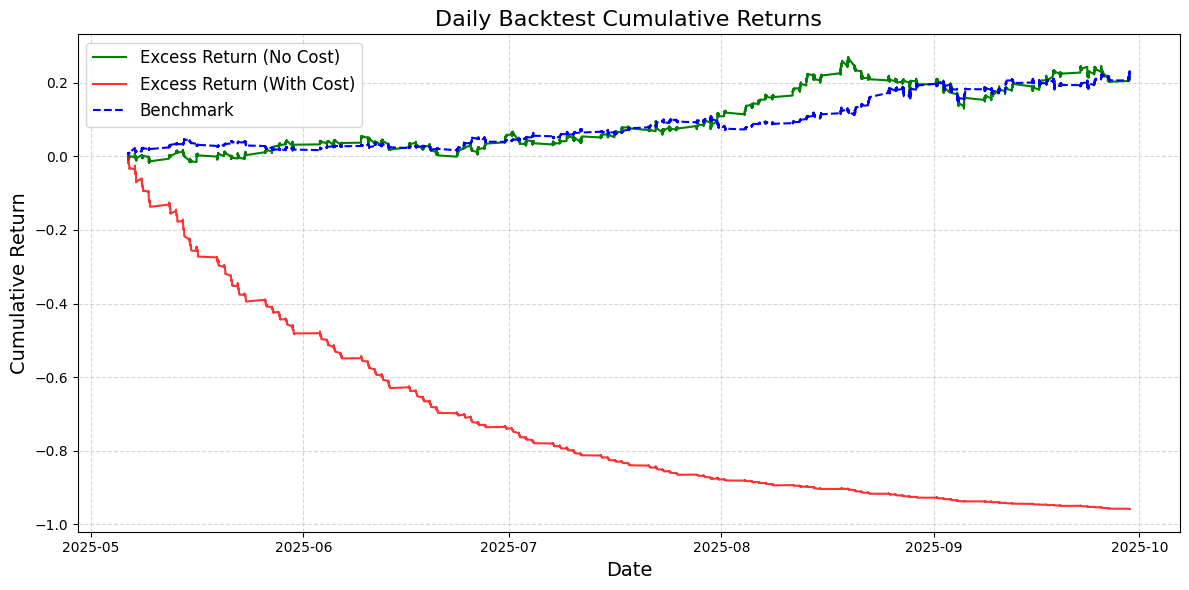

In [17]:
import matplotlib.pyplot as plt
import pandas as pd


# 1) Compute cumulative returns
cum_return_wo_cost = (1 + (report['return'] - report['bench'])).cumprod() - 1  # excess return without cost
cum_return_w_cost = (1 + (report['return'] - report['bench'] - report['cost'])).cumprod() - 1  # with cost
cum_bench = (1 + report['bench']).cumprod() - 1  # benchmark

# 2) Plot
plt.figure(figsize=(12,6))
plt.plot(cum_return_wo_cost, label='Excess Return (No Cost)', color='green')
plt.plot(cum_return_w_cost, label='Excess Return (With Cost)', color='red', alpha=0.8)
plt.plot(cum_bench, label='Benchmark', color='blue', linestyle='--')

plt.title("Daily Backtest Cumulative Returns", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [ ]:
# 检查调仓频率 - 按天统计
pos = recorder.load_object("portfolio_analysis/positions_normal_1min.pkl")
held = pos.apply(lambda s: set(s.dropna().index), axis=1)
changed = held != held.shift(1)

# 按天统计调仓次数
pos.index = pd.to_datetime(pos.index)
daily_changes = changed.groupby(pos.index.date).sum()
print("每日调仓次数统计:")
print(daily_changes.describe())
print(f"平均每日调仓次数: {daily_changes.mean():.2f}")
print(f"最大单日调仓次数: {daily_changes.max()}")
print(f"调仓次数>0的天数: {(daily_changes > 0).sum()}/{len(daily_changes)}")

# 检查是否真的每分钟都在调仓
print(f"总分钟数: {len(changed)}")
print(f"调仓分钟数: {changed.sum()}")
print(f"调仓比例: {changed.mean():.3f}")

AttributeError: 'dict' object has no attribute 'apply'